#Chat Inspections

##Data Collection

In [5]:
!pip install textblob

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import graphviz

from sklearn.feature_extraction.text import TfidfVectorizer
from textblob import TextBlob
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
  accuracy_score,
  precision_score,
  recall_score,
  f1_score,
  roc_auc_score,
  classification_report
)

df = pd.read_parquet('https://huggingface.co/datasets/ddds-Capstone/Datasets/resolve/main/chat_metrics.parquet')


##TF-IDF
Term Frequency-Inverse Document Frequency

In [4]:
#Question TF-IDF
tfidf_question = TfidfVectorizer(max_features=500, stop_words='english')

question_tfidf = tfidf_question.fit_transform(df['question_en'].fillna(''))

question_features = tfidf_question.get_feature_names_out()

#Weight of each word across all questions
scores = np.asarray(question_tfidf.sum(axis=0)).flatten()

top_words = pd.DataFrame({'word': question_features, 'tfidf_score':scores}).sort_values('tfidf_score', ascending=False)

#Answer TF-IDF
tfidf_answer = TfidfVectorizer(max_features=500, stop_words='english')

answer_tfidf = tfidf_answer.fit_transform(df['answer_en'].fillna(''))

answer_features = tfidf_answer.get_feature_names_out()

#Weight of each word across all questions
scores = np.asarray(answer_tfidf.sum(axis=0)).flatten()

top_words = pd.DataFrame({'word': answer_features, 'tfidf_score':scores}).sort_values('tfidf_score', ascending=False)
top_words.head(20)

,word,tfidf_score
449,td,38.171470
264,information,27.945269
445,sunport,27.544662
71,albuquerque,24.184012
471,tsa,22.620104
58,abq,22.298030
453,terminal,21.776694
268,international,20.188348
256,https,19.798388
140,com,19.229386


##Sentiment Analysis

In [9]:
df['polarity'] = df['answer_en'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
df['subjectivity'] = df['answer_en'].apply(lambda x: TextBlob(str(x)).sentiment.subjectivity)

df['polarity'] = df['question_en'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
df['subjectivity'] = df['question_en'].apply(lambda x: TextBlob(str(x)).sentiment.subjectivity)

##Make a Copy

In [10]:
df_clean = df.copy()

##Data Cleaning

In [11]:
#Keep sessions with star_rating only
df_clean.dropna(subset=['star_rating'], inplace=True)

#Binary Satisfaction
df_clean['satisfaction'] = (df_clean['star_rating'] >= 4).astype(int)

df_clean['satisfaction'].value_counts(normalize=True)

#Set target
target = 'satisfaction'

##Processing

In [14]:
features = [

  #Time
  'day_sin',
  'day_cos',
  'hour_sin',
  'hour_cos',
  'month_sin',
  'month_cos',

  #Performance
  'processing_time_seconds',
  'total_tokens',
  'input_tokens',
  'output_tokens',
  'model_calls',
  'tool_calls_count',

  #Q&A
  'question_length',
  'answer_length',

  #Maps
  'has_geolocation',

  #Primary Category
  'primary_category_greetings',
  'primary_category_sunport_amenities',
  'primary_category_navigation',
  'primary_category_airline_logistics',
  'primary_category_general_info',

  #Selected Agent
  'selected_agentreporter',
  'selected_agentplanner',
  'selected_agentlocation',
  'selected_agentlocation_fallback_to_reporter',
  'selected_agentbroad_search_synthesis',
  'selected_agentbroad_search_passthrough',

  #Sentiment
  'polarity',
  'subjectivity'
]

In [15]:
X = df_clean[features]
y = df_clean[target]

###Train/test split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
  X,
  y,
  test_size=0.20,
  random_state=42,
  stratify=y #Maintains roughly same proportion
)

###Scale

In [20]:
#Split data
X_train, X_test, y_train, y_test = train_test_split(
  X,
  y,
  test_size=0.20,
  random_state=42
)

#Initialize scaler
scaler = StandardScaler()

#Fit and transform training data
X_train = scaler.fit_transform(X_train)

#Transform (DO NOT fit again)
X_test = scaler.transform(X_test)

X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

#Split scaled data
X_train, X_test, y_train, y_test = train_test_split(
  X_scaled,
  y,
  test_size=0.20,
  random_state=42
)

###Logistic Regression

In [21]:
#Create model
lr = LogisticRegression()

#Fit
lr.fit(X_train, y_train)

#Make predictions
y_pred_lr = lr.predict(X_test)

#Probability
y_prob_lr = lr.predict_proba(X_test)[:,1]

#Evaluate
print('Accuracy:', accuracy_score(y_test, y_pred_lr))
print('Precision:', precision_score(y_test, y_pred_lr))
print('Recall:', recall_score(y_test, y_pred_lr))
print('F1:', f1_score(y_test, y_pred_lr))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_lr))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.735632183908046
Precision: 0.8
Recall: 0.6363636363636364
F1: 0.7088607594936709
ROC-AUC: 0.8007399577167019

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.84      0.76        43
           1       0.80      0.64      0.71        44

    accuracy                           0.74        87
   macro avg       0.75      0.74      0.73        87
weighted avg       0.75      0.74      0.73        87



In [22]:
#Cross Validation
#Use X_scaled to fix convergence issues and 'accuracy' for classification
results = cross_val_score(
  lr,
  X_scaled,
  y,
  scoring='accuracy',
  cv=10
)

#Accuracy across  10 folds
cv_accuracy = results.mean()
print('CV Accuracy:', cv_accuracy)

CV Accuracy: 0.7200317124735731


###Decision Tree

In [23]:
#Model
dt = DecisionTreeClassifier(
  max_depth=3,
  random_state=42
)

#Fit
dt.fit(X_train, y_train)

#Predict
y_pred_dt = dt.predict(X_test)

#Probability
y_prob_dt = dt.predict_proba(X_test)[:,1]

print('Accuracy:', accuracy_score(y_test, y_pred_dt))
print('Precision:', precision_score(y_test, y_pred_dt))
print('Recall:', recall_score(y_test, y_pred_dt))
print('F1:', f1_score(y_test, y_pred_dt))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_dt))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.7126436781609196
Precision: 0.6610169491525424
Recall: 0.8863636363636364
F1: 0.7572815533980582
ROC-AUC: 0.7936046511627908

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.53      0.65        43
           1       0.66      0.89      0.76        44

    accuracy                           0.71        87
   macro avg       0.74      0.71      0.70        87
weighted avg       0.74      0.71      0.70        87



In [24]:
#Cross Validation
scores = cross_val_score(
  dt,
  X_train,
  y_train,
  cv=5,
  scoring='accuracy'
)

print('CV Accuracy Scores for each fold:', scores)
print('Mean CV Accuracy:', scores.mean())

CV Accuracy Scores for each fold: [0.60869565 0.60869565 0.71014493 0.73913043 0.79710145]
Mean CV Accuracy: 0.6927536231884058


In [25]:
#Find depth
depths = range(1,11)

results = []

for depth in depths:

  tree_model = DecisionTreeClassifier(
    max_depth=depth,
    random_state=42
  )

  scores = cross_val_score(
    tree_model,
    X_train,
    y_train,
    cv=5,
    scoring = 'accuracy'
  )

  results.append({
    'max_depth': depth,
    'accuracy': scores.mean()
  })

results_df = pd.DataFrame(results)
results_df.sort_values(by='accuracy', ascending=False)

,max_depth,accuracy
4,5,0.695652
2,3,0.692754
3,4,0.684058
1,2,0.681159
5,6,0.669565
0,1,0.663768
7,8,0.660870
9,10,0.652174
6,7,0.649275
8,9,0.646377


In [26]:
#Final
dt = DecisionTreeClassifier(
  max_depth=5,
  random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

print('Accuracy:', accuracy_score(y_test, y_pred_dt))
print('Precision:', precision_score(y_test, y_pred_dt))
print('Recall:', recall_score(y_test, y_pred_dt))
print('F1:', f1_score(y_test, y_pred_dt))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_dt))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.6896551724137931
Precision: 0.6808510638297872
Recall: 0.7272727272727273
F1: 0.7032967032967034
ROC-AUC: 0.7748414376321353

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.65      0.67        43
           1       0.68      0.73      0.70        44

    accuracy                           0.69        87
   macro avg       0.69      0.69      0.69        87
weighted avg       0.69      0.69      0.69        87



In [27]:
#Feature importance
dt_importances = pd.Series(
  dt.feature_importances_,
  index=features
).sort_values(ascending=False)

dt_importances.head(10)

,0
output_tokens,0.325801
answer_length,0.101058
model_calls,0.095598
month_sin,0.084744
total_tokens,0.084411
month_cos,0.063089
subjectivity,0.059411
question_length,0.057058
polarity,0.041734
processing_time_seconds,0.033330


###Random Forest

In [28]:
rf = RandomForestClassifier(
  n_estimators=100, #Build 100 individual trees
  max_depth=3,      #Each tree grows max of 3 depths
  random_state=42,  #Makes results reproducable
  n_jobs=-1         #Uses all available CPU cores
)

#Fit
rf.fit(X_train, y_train)

#Predict
y_pred_rf = rf.predict(X_test)

#Probability
y_prob_rf = rf.predict_proba(X_test)[:,1]

print('Accuracy:', accuracy_score(y_test, y_pred_rf))
print('Precision:', precision_score(y_test, y_pred_rf))
print('Recall:', recall_score(y_test, y_pred_rf))
print('F1:', f1_score(y_test, y_pred_rf))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_rf))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.6781609195402298
Precision: 0.6904761904761905
Recall: 0.6590909090909091
F1: 0.6744186046511628
ROC-AUC: 0.8017970401691332

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.70      0.68        43
           1       0.69      0.66      0.67        44

    accuracy                           0.68        87
   macro avg       0.68      0.68      0.68        87
weighted avg       0.68      0.68      0.68        87



In [29]:
#Tune max_depth
results = []

for depth in depths:

  rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=depth,
    random_state=42,
    n_jobs=-1
  )

  scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring = 'accuracy'
  )

  results.append({
    'max_depth': depth,
    'accuracy': scores.mean()
  })

results_df = pd.DataFrame(results)
results_df.sort_values(by='accuracy', ascending=False)

,max_depth,accuracy
7,8,0.762319
5,6,0.762319
8,9,0.759420
9,10,0.759420
6,7,0.753623
3,4,0.750725
4,5,0.750725
2,3,0.736232
1,2,0.701449
0,1,0.669565


In [30]:
#Tune n_estimators
n_estimators_values = [50, 100, 200, 300, 500]

results = []

for n in n_estimators_values:

  forest = RandomForestClassifier(
    n_estimators=n,
    max_depth=8,
    random_state=42,
    n_jobs=-1
  )

  scores = cross_val_score(
    forest,
    X_train,
    y_train,
    cv=5,
    scoring = 'accuracy'
  )

  rmse_scores = -scores

  results.append({
    'n_estimators': n,
    'accuracy': scores.mean()
  })

results_df = pd.DataFrame(results)
results_df.sort_values(by='accuracy', ascending=False)

,n_estimators,accuracy
0,50,0.768116
2,200,0.768116
3,300,0.768116
1,100,0.762319
4,500,0.762319


In [31]:
#Final
rf = RandomForestClassifier(
  n_estimators=50,
  max_depth=8,
  random_state=42,
  n_jobs=-1
)

#Fit
rf.fit(X_train, y_train)

#Predict
y_pred_rf = rf.predict(X_test)

#Probability
y_prob_rf = rf.predict_proba(X_test)[:,1]

print('Accuracy:', accuracy_score(y_test, y_pred_rf))
print('Precision:', precision_score(y_test, y_pred_rf))
print('Recall:', recall_score(y_test, y_pred_rf))
print('F1:', f1_score(y_test, y_pred_rf))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_rf))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7241379310344828
Precision: 0.7272727272727273
Recall: 0.7272727272727273
F1: 0.7272727272727273
ROC-AUC: 0.8012684989429176

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.72      0.72        43
           1       0.73      0.73      0.73        44

    accuracy                           0.72        87
   macro avg       0.72      0.72      0.72        87
weighted avg       0.72      0.72      0.72        87



###XGBoost

In [32]:
#Create baseline model
xgb = XGBClassifier(
  n_estimators=100,   #Boosting rounds/trees
  learning_rate=0.05, #Controls how much each new tree contributest to model
  max_depth=3,        #Max deptho or each tree
  random_state=42,
  objective = 'binary:logistic', # Tells XGBoost to do binary classification
  eval_metric='logloss'
)

#Fit
xgb.fit(X_train, y_train)

#Predict
y_pred_xgb = xgb.predict(X_test)

#Probability
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

print('Accuracy:', accuracy_score(y_test, y_pred_xgb))
print('Precision:', precision_score(y_test, y_pred_xgb))
print('Recall:', recall_score(y_test, y_pred_xgb))
print('F1:', f1_score(y_test, y_pred_xgb))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_xgb))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.7241379310344828
Precision: 0.7272727272727273
Recall: 0.7272727272727273
F1: 0.7272727272727273
ROC-AUC: 0.8171247357293869

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.72      0.72        43
           1       0.73      0.73      0.73        44

    accuracy                           0.72        87
   macro avg       0.72      0.72      0.72        87
weighted avg       0.72      0.72      0.72        87



In [33]:
#Tune max_depth
results = []

for depth in depths:

  xgb = XGBClassifier(
    n_estimators=100,
    max_depth=depth,
    random_state=42,
    objective = 'binary:logistic', # Tells XGBoost to do binary classification
    eval_metric='logloss'
  )

  scores = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=5,
    scoring = 'accuracy'
  )

  results.append({
    'max_depth': depth,
    'accuracy': scores.mean()
  })

results_df = pd.DataFrame(results)
results_df.sort_values(by='accuracy', ascending=False)

,max_depth,accuracy
4,5,0.742029
2,3,0.742029
6,7,0.742029
0,1,0.730435
1,2,0.724638
3,4,0.724638
9,10,0.721739
8,9,0.715942
5,6,0.710145
7,8,0.707246


In [34]:
#Tune n_estimators
n_estimators_values = [50, 100, 200, 300, 500]

results = []

for n in n_estimators_values:

  forest = XGBClassifier(
    n_estimators=n,
    max_depth=5,
    random_state=42,
    objective = 'binary:logistic', # Tells XGBoost to do binary classification
    eval_metric='logloss'
  )

  scores = cross_val_score(
    forest,
    X_train,
    y_train,
    cv=5,
    scoring = 'accuracy'
  )

  results.append({
    'n_estimators': n,
    'accuracy': scores.mean()
  })

results_df = pd.DataFrame(results)
results_df.sort_values(by='accuracy', ascending=False)

,n_estimators,accuracy
1,100,0.742029
2,200,0.736232
4,500,0.736232
0,50,0.733333
3,300,0.733333


In [35]:
#Tune learning_rate
learning_rates = [0.01, 0.05, 0.1, 0.2]

results = []

for n in learning_rates:

  xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=n,
    max_depth=5,
    random_state=42,
    objective = 'reg:squarederror'
  )

  scores = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=5,
    scoring = 'accuracy'
  )

  rmse_scores = -scores

  results.append({
    'learning_rate': n,
    'accuracy': scores.mean()
  })

results_df = pd.DataFrame(results)
results_df.sort_values(by='accuracy', ascending=False)

,learning_rate,accuracy
0,0.01,0.718841
1,0.05,0.713043
2,0.10,0.710145
3,0.20,0.704348


In [36]:
#Final XGBoost model
xgb = XGBClassifier(
  n_estimators=100,   #Boosting rounds/trees
  learning_rate=0.01, #Controls how much each new tree contributest to model
  max_depth=5,        #Max deptho or each tree
  random_state=42,
  objective = 'binary:logistic', # Tells XGBoost to do binary classification
  eval_metric='logloss'
)

#Fit
xgb.fit(X_train, y_train)

#Predict
y_pred_xgb = xgb.predict(X_test)

#Probability
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

print('Accuracy:', accuracy_score(y_test, y_pred_xgb))
print('Precision:', precision_score(y_test, y_pred_xgb))
print('Recall:', recall_score(y_test, y_pred_xgb))
print('F1:', f1_score(y_test, y_pred_xgb))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_xgb))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.7471264367816092
Precision: 0.7391304347826086
Recall: 0.7727272727272727
F1: 0.7555555555555555
ROC-AUC: 0.8237315010570826

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.72      0.74        43
           1       0.74      0.77      0.76        44

    accuracy                           0.75        87
   macro avg       0.75      0.75      0.75        87
weighted avg       0.75      0.75      0.75        87



In [37]:
#Feature importance
xgb_importances = pd.Series(
  xgb.feature_importances_,
  index=features
).sort_values(ascending=False)

xgb_importances.head(10)

,0
output_tokens,0.234726
model_calls,0.129863
subjectivity,0.095217
month_sin,0.084670
answer_length,0.057860
day_cos,0.054075
hour_sin,0.046980
question_length,0.040987
tool_calls_count,0.038570
total_tokens,0.036288


##Data Visualization

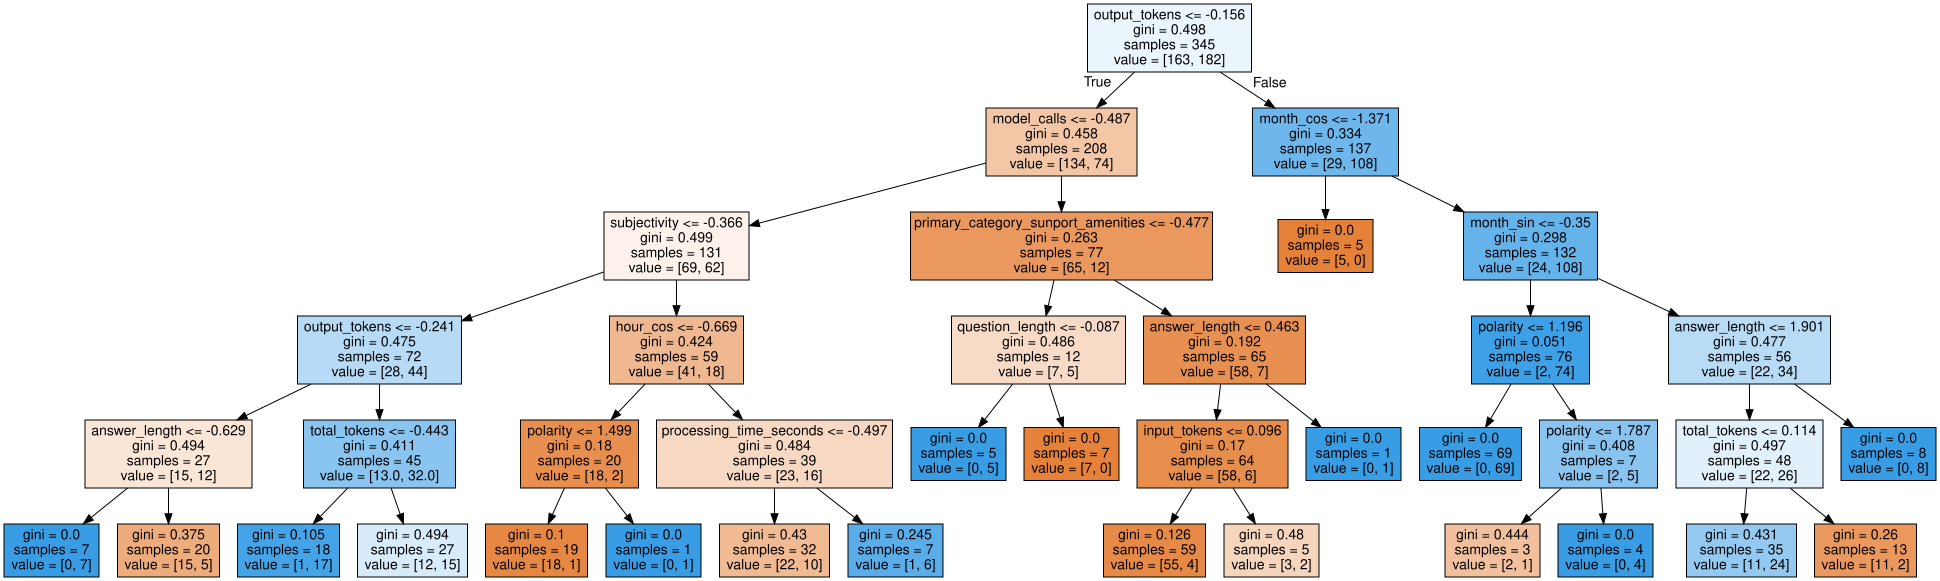

In [38]:
display(
  graphviz.Source(
    tree.export_graphviz(
      dt,
      feature_names = X.columns,
      filled = True,
    )))

<Axes: title={'center': 'Decision Tree Feature Importance'}>

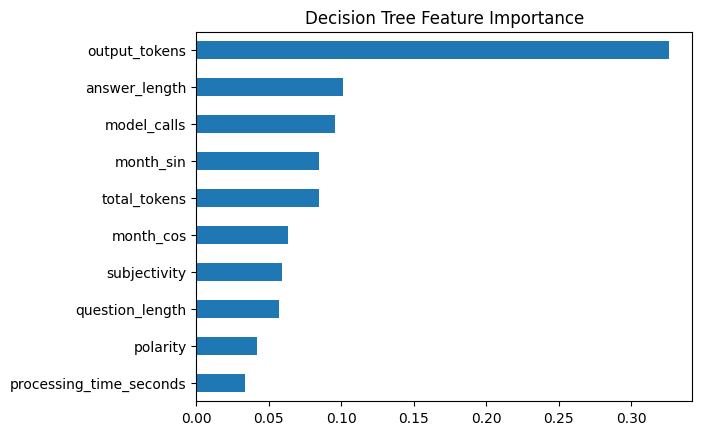

In [39]:
dt_importances.head(10).sort_values().plot(
  kind='barh',
  title='Decision Tree Feature Importance'
)

<Axes: title={'center': 'Random Forest Feature Importance'}>

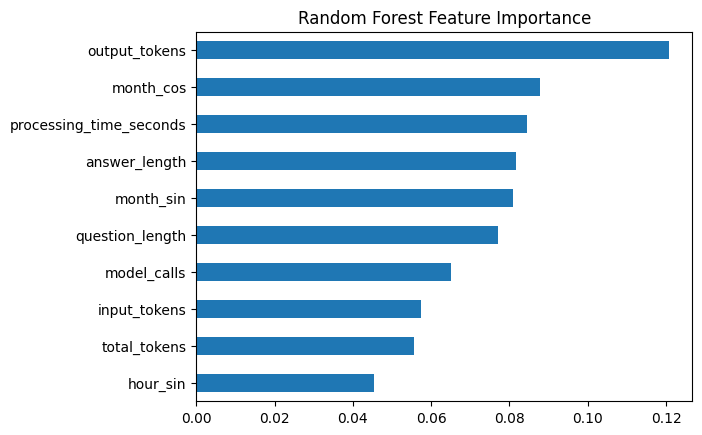

In [40]:
#Feature importance
forest_importances = pd.Series(
  rf.feature_importances_,
  index=features
).sort_values(ascending=False)

#Plot
forest_importances.head(10).sort_values().plot(
  kind='barh',
  title='Random Forest Feature Importance'
)

<Axes: title={'center': 'XGBoost Feature Importance'}>

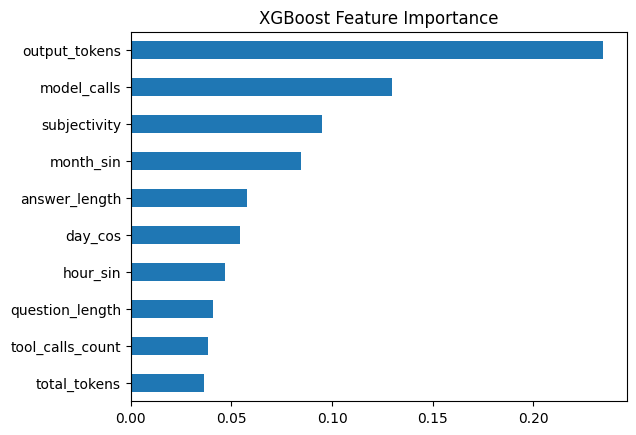

In [41]:
xgb_importances.head(10).sort_values().plot(
  kind='barh',
  title='XGBoost Feature Importance'
)

In [55]:
results = pd.DataFrame({
  'Model': ['Decision Tree', 'Random Forest', 'XGBoost'],

  'Accuracy': [
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_xgb)
  ],

  'F1': [
    f1_score(y_test, y_pred_dt),
    f1_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_xgb)
  ],

  'ROC-AUC': [
    roc_auc_score(y_test, y_prob_dt),
    roc_auc_score(y_test, y_prob_rf),
    roc_auc_score(y_test, y_prob_xgb)
  ]
})

results

ValueError: All arrays must be of the same length

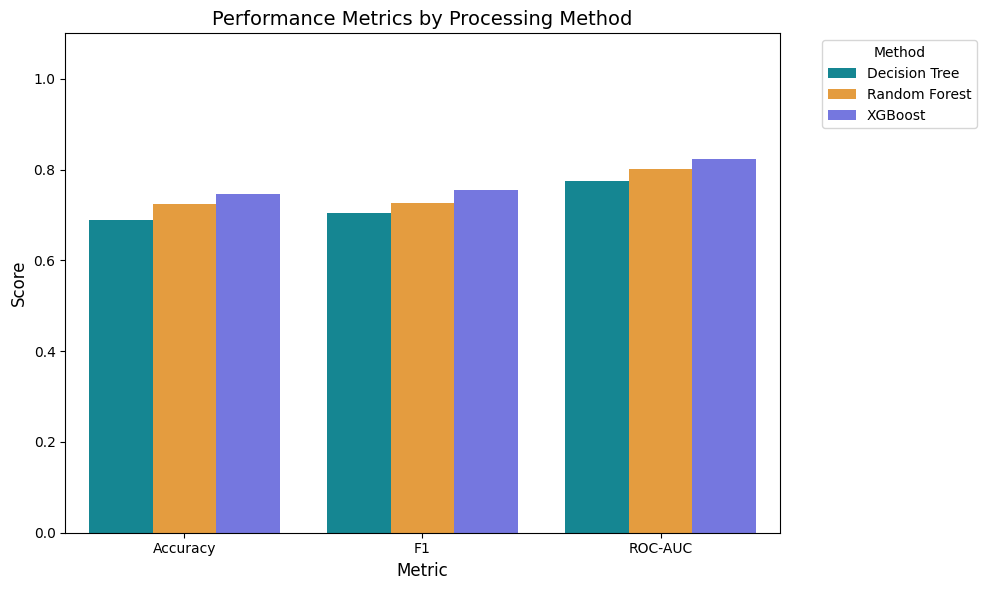

In [45]:
#Melt df to restructure for Seaborn
results_melted = results.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(
    data=results_melted,
    x='Metric',
    y='Score',
    hue='Model',
    palette=['#0097A7', '#FF9F24',  '#6366F1']
)

plt.title('Performance Metrics by Processing Method', fontsize=14)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Metric', fontsize=12)
plt.ylim(0, 1.1) #Headroom

#Move legend
plt.legend(title='Method', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig('evaluation.png', dpi=300, bbox_inches='tight')

plt.show()

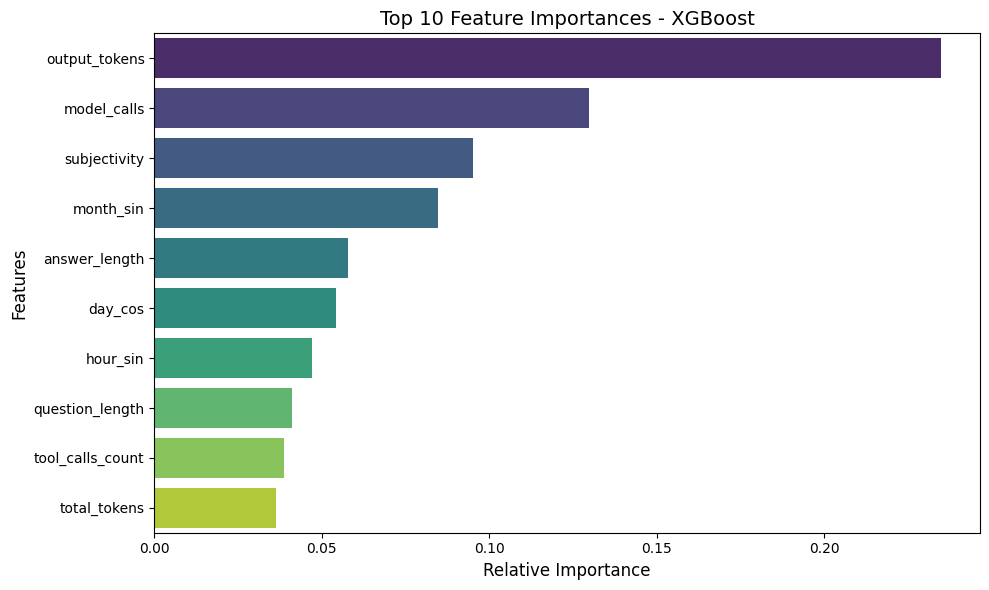

In [46]:
#Create df for XGBoost importance features
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': xgb.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))

#Create horizontal barplot
sns.barplot(
    data=feature_importance.head(10),
    x='importance',
    y='feature',
    hue='feature',
    palette='viridis',
    legend=False
)

plt.title('Top 10 Feature Importances - XGBoost', fontsize=14)
plt.xlabel('Relative Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)

plt.tight_layout()

plt.savefig('important_features.png', dpi=300, bbox_inches='tight')

plt.show()

##Communication of Results

In [47]:
importance_comparison = pd.DataFrame({
  'Decision Tree': dt_importances,
  'Random Forest': forest_importances,
  'XGBoost': xgb_importances
})

importance_comparison

,Decision Tree,Random Forest,XGBoost
answer_length,0.101058,0.081751,0.057860
day_cos,0.000000,0.013960,0.054075
day_sin,0.000000,0.021171,0.023196
has_geolocation,0.000000,0.006499,0.000000
hour_cos,0.024895,0.032329,0.030959
hour_sin,0.000000,0.045262,0.046980
input_tokens,0.009951,0.057377,0.030607
model_calls,0.095598,0.065130,0.129863
month_cos,0.063089,0.087670,0.000000
month_sin,0.084744,0.080926,0.084670


#Top 10

##Processing

In [50]:
features = [
  'output_tokens',
  'model_calls',
  'subjectivity',
  'month_sin',
  'answer_length',
  'day_cos',
  'hour_sin',
  'question_length',
  'tool_calls_count',
  'total_tokens'
]

In [51]:
X = df_clean[features]
y = df_clean[target]

###Train/test split

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
  X,
  y,
  test_size=0.20,
  random_state=42,
  stratify=y #Maintains roughly same proportion
)

###Scale

In [53]:
#Split data
X_train, X_test, y_train, y_test = train_test_split(
  X,
  y,
  test_size=0.20,
  random_state=42
)

#Initialize scaler
scaler = StandardScaler()

#Fit and transform training data
X_train = scaler.fit_transform(X_train)

#Transform (DO NOT fit again)
X_test = scaler.transform(X_test)

X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

#Split scaled data
X_train, X_test, y_train, y_test = train_test_split(
  X_scaled,
  y,
  test_size=0.20,
  random_state=42
)

###Logistic Regression

In [56]:
#Create model
lr = LogisticRegression()

#Fit
lr.fit(X_train, y_train)

#Make predictions
y_pred_lr = lr.predict(X_test)

#Probability
y_prob_lr = lr.predict_proba(X_test)[:,1]

#Evaluate
print('Accuracy:', accuracy_score(y_test, y_pred_lr))
print('Precision:', precision_score(y_test, y_pred_lr))
print('Recall:', recall_score(y_test, y_pred_lr))
print('F1:', f1_score(y_test, y_pred_lr))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_lr))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.7241379310344828
Precision: 0.7777777777777778
Recall: 0.6363636363636364
F1: 0.7
ROC-AUC: 0.8007399577167019

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.81      0.74        43
           1       0.78      0.64      0.70        44

    accuracy                           0.72        87
   macro avg       0.73      0.73      0.72        87
weighted avg       0.73      0.72      0.72        87



In [57]:
#Cross Validation
#Use X_scaled to fix convergence issues and 'accuracy' for classification
results = cross_val_score(
  lr,
  X_scaled,
  y,
  scoring='accuracy',
  cv=10
)

#Accuracy across  10 folds
cv_accuracy = results.mean()
print('CV Accuracy:', cv_accuracy)

CV Accuracy: 0.6945560253699788


###Decision Tree

In [58]:
#Model
dt = DecisionTreeClassifier(
  max_depth=3,
  random_state=42
)

#Fit
dt.fit(X_train, y_train)

#Predict
y_pred_dt = dt.predict(X_test)

#Probability
y_prob_dt = dt.predict_proba(X_test)[:,1]

print('Accuracy:', accuracy_score(y_test, y_pred_dt))
print('Precision:', precision_score(y_test, y_pred_dt))
print('Recall:', recall_score(y_test, y_pred_dt))
print('F1:', f1_score(y_test, y_pred_dt))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_dt))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.7126436781609196
Precision: 0.6610169491525424
Recall: 0.8863636363636364
F1: 0.7572815533980582
ROC-AUC: 0.7967758985200845

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.53      0.65        43
           1       0.66      0.89      0.76        44

    accuracy                           0.71        87
   macro avg       0.74      0.71      0.70        87
weighted avg       0.74      0.71      0.70        87



In [59]:
#Cross Validation
scores = cross_val_score(
  dt,
  X_train,
  y_train,
  cv=5,
  scoring='accuracy'
)

print('CV Accuracy Scores for each fold:', scores)
print('Mean CV Accuracy:', scores.mean())

CV Accuracy Scores for each fold: [0.60869565 0.60869565 0.71014493 0.73913043 0.79710145]
Mean CV Accuracy: 0.6927536231884058


In [60]:
#Find depth
depths = range(1,11)

results = []

for depth in depths:

  tree_model = DecisionTreeClassifier(
    max_depth=depth,
    random_state=42
  )

  scores = cross_val_score(
    tree_model,
    X_train,
    y_train,
    cv=5,
    scoring = 'accuracy'
  )

  results.append({
    'max_depth': depth,
    'accuracy': scores.mean()
  })

results_df = pd.DataFrame(results)
results_df.sort_values(by='accuracy', ascending=False)

,max_depth,accuracy
2,3,0.692754
3,4,0.689855
8,9,0.686957
4,5,0.684058
1,2,0.681159
7,8,0.675362
6,7,0.672464
9,10,0.669565
0,1,0.663768
5,6,0.663768


In [61]:
#Final
dt = DecisionTreeClassifier(
  max_depth=3,
  random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

print('Accuracy:', accuracy_score(y_test, y_pred_dt))
print('Precision:', precision_score(y_test, y_pred_dt))
print('Recall:', recall_score(y_test, y_pred_dt))
print('F1:', f1_score(y_test, y_pred_dt))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_dt))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.7126436781609196
Precision: 0.6610169491525424
Recall: 0.8863636363636364
F1: 0.7572815533980582
ROC-AUC: 0.7967758985200845

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.53      0.65        43
           1       0.66      0.89      0.76        44

    accuracy                           0.71        87
   macro avg       0.74      0.71      0.70        87
weighted avg       0.74      0.71      0.70        87



In [62]:
#Feature importance
dt_importances = pd.Series(
  dt.feature_importances_,
  index=features
).sort_values(ascending=False)

dt_importances.head(10)

,0
output_tokens,0.486043
month_sin,0.264752
model_calls,0.153692
subjectivity,0.095513
answer_length,0.000000
day_cos,0.000000
hour_sin,0.000000
question_length,0.000000
tool_calls_count,0.000000
total_tokens,0.000000


###Random Forest

In [63]:
rf = RandomForestClassifier(
  n_estimators=100, #Build 100 individual trees
  max_depth=3,      #Each tree grows max of 3 depths
  random_state=42,  #Makes results reproducable
  n_jobs=-1         #Uses all available CPU cores
)

#Fit
rf.fit(X_train, y_train)

#Predict
y_pred_rf = rf.predict(X_test)

#Probability
y_prob_rf = rf.predict_proba(X_test)[:,1]

print('Accuracy:', accuracy_score(y_test, y_pred_rf))
print('Precision:', precision_score(y_test, y_pred_rf))
print('Recall:', recall_score(y_test, y_pred_rf))
print('F1:', f1_score(y_test, y_pred_rf))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_rf))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7126436781609196
Precision: 0.7021276595744681
Recall: 0.75
F1: 0.7252747252747253
ROC-AUC: 0.7832980972515857

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.67      0.70        43
           1       0.70      0.75      0.73        44

    accuracy                           0.71        87
   macro avg       0.71      0.71      0.71        87
weighted avg       0.71      0.71      0.71        87



In [64]:
#Tune max_depth
results = []

for depth in depths:

  rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=depth,
    random_state=42,
    n_jobs=-1
  )

  scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring = 'accuracy'
  )

  results.append({
    'max_depth': depth,
    'accuracy': scores.mean()
  })

results_df = pd.DataFrame(results)
results_df.sort_values(by='accuracy', ascending=False)

,max_depth,accuracy
5,6,0.747826
3,4,0.742029
4,5,0.739130
7,8,0.733333
2,3,0.733333
8,9,0.733333
9,10,0.730435
6,7,0.730435
1,2,0.704348
0,1,0.686957


In [65]:
#Tune n_estimators
n_estimators_values = [50, 100, 200, 300, 500]

results = []

for n in n_estimators_values:

  forest = RandomForestClassifier(
    n_estimators=n,
    max_depth=6,
    random_state=42,
    n_jobs=-1
  )

  scores = cross_val_score(
    forest,
    X_train,
    y_train,
    cv=5,
    scoring = 'accuracy'
  )

  rmse_scores = -scores

  results.append({
    'n_estimators': n,
    'accuracy': scores.mean()
  })

results_df = pd.DataFrame(results)
results_df.sort_values(by='accuracy', ascending=False)

,n_estimators,accuracy
2,200,0.762319
4,500,0.756522
3,300,0.756522
0,50,0.747826
1,100,0.747826


In [66]:
#Final
rf = RandomForestClassifier(
  n_estimators=200,
  max_depth=6,
  random_state=42,
  n_jobs=-1
)

#Fit
rf.fit(X_train, y_train)

#Predict
y_pred_rf = rf.predict(X_test)

#Probability
y_prob_rf = rf.predict_proba(X_test)[:,1]

print('Accuracy:', accuracy_score(y_test, y_pred_rf))
print('Precision:', precision_score(y_test, y_pred_rf))
print('Recall:', recall_score(y_test, y_pred_rf))
print('F1:', f1_score(y_test, y_pred_rf))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_rf))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7126436781609196
Precision: 0.7021276595744681
Recall: 0.75
F1: 0.7252747252747253
ROC-AUC: 0.8118393234672305

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.67      0.70        43
           1       0.70      0.75      0.73        44

    accuracy                           0.71        87
   macro avg       0.71      0.71      0.71        87
weighted avg       0.71      0.71      0.71        87



###XGBoost

In [67]:
#Create baseline model
xgb = XGBClassifier(
  n_estimators=100,   #Boosting rounds/trees
  learning_rate=0.05, #Controls how much each new tree contributest to model
  max_depth=3,        #Max deptho or each tree
  random_state=42,
  objective = 'binary:logistic', # Tells XGBoost to do binary classification
  eval_metric='logloss'
)

#Fit
xgb.fit(X_train, y_train)

#Predict
y_pred_xgb = xgb.predict(X_test)

#Probability
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

print('Accuracy:', accuracy_score(y_test, y_pred_xgb))
print('Precision:', precision_score(y_test, y_pred_xgb))
print('Recall:', recall_score(y_test, y_pred_xgb))
print('F1:', f1_score(y_test, y_pred_xgb))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_xgb))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.7241379310344828
Precision: 0.7083333333333334
Recall: 0.7727272727272727
F1: 0.7391304347826086
ROC-AUC: 0.8076109936575053

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.67      0.71        43
           1       0.71      0.77      0.74        44

    accuracy                           0.72        87
   macro avg       0.73      0.72      0.72        87
weighted avg       0.73      0.72      0.72        87



In [68]:
#Tune max_depth
results = []

for depth in depths:

  xgb = XGBClassifier(
    n_estimators=100,
    max_depth=depth,
    random_state=42,
    objective = 'binary:logistic', # Tells XGBoost to do binary classification
    eval_metric='logloss'
  )

  scores = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=5,
    scoring = 'accuracy'
  )

  results.append({
    'max_depth': depth,
    'accuracy': scores.mean()
  })

results_df = pd.DataFrame(results)
results_df.sort_values(by='accuracy', ascending=False)

,max_depth,accuracy
3,4,0.744928
2,3,0.742029
4,5,0.742029
1,2,0.736232
6,7,0.736232
0,1,0.733333
8,9,0.730435
5,6,0.727536
7,8,0.727536
9,10,0.721739


In [69]:
#Tune n_estimators
n_estimators_values = [50, 100, 200, 300, 500]

results = []

for n in n_estimators_values:

  forest = XGBClassifier(
    n_estimators=n,
    max_depth=4,
    random_state=42,
    objective = 'binary:logistic', # Tells XGBoost to do binary classification
    eval_metric='logloss'
  )

  scores = cross_val_score(
    forest,
    X_train,
    y_train,
    cv=5,
    scoring = 'accuracy'
  )

  results.append({
    'n_estimators': n,
    'accuracy': scores.mean()
  })

results_df = pd.DataFrame(results)
results_df.sort_values(by='accuracy', ascending=False)

,n_estimators,accuracy
0,50,0.759420
2,200,0.753623
4,500,0.750725
1,100,0.744928
3,300,0.744928


In [70]:
#Tune learning_rate
learning_rates = [0.01, 0.05, 0.1, 0.2]

results = []

for n in learning_rates:

  xgb = XGBClassifier(
    n_estimators=50,
    learning_rate=n,
    max_depth=4,
    random_state=42,
    objective = 'reg:squarederror'
  )

  scores = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=5,
    scoring = 'accuracy'
  )

  rmse_scores = -scores

  results.append({
    'learning_rate': n,
    'accuracy': scores.mean()
  })

results_df = pd.DataFrame(results)
results_df.sort_values(by='accuracy', ascending=False)

,learning_rate,accuracy
2,0.10,0.750725
1,0.05,0.733333
3,0.20,0.701449
0,0.01,0.698551


In [71]:
#Final XGBoost model
xgb = XGBClassifier(
  n_estimators=50,   #Boosting rounds/trees
  learning_rate=0.10, #Controls how much each new tree contributest to model
  max_depth=4,        #Max deptho or each tree
  random_state=42,
  objective = 'binary:logistic', # Tells XGBoost to do binary classification
  eval_metric='logloss'
)

#Fit
xgb.fit(X_train, y_train)

#Predict
y_pred_xgb = xgb.predict(X_test)

#Probability
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

print('Accuracy:', accuracy_score(y_test, y_pred_xgb))
print('Precision:', precision_score(y_test, y_pred_xgb))
print('Recall:', recall_score(y_test, y_pred_xgb))
print('F1:', f1_score(y_test, y_pred_xgb))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_xgb))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.6781609195402298
Precision: 0.6538461538461539
Recall: 0.7727272727272727
F1: 0.7083333333333334
ROC-AUC: 0.8004756871035941

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.58      0.64        43
           1       0.65      0.77      0.71        44

    accuracy                           0.68        87
   macro avg       0.68      0.68      0.67        87
weighted avg       0.68      0.68      0.68        87



In [72]:
#Feature importance
xgb_importances = pd.Series(
  xgb.feature_importances_,
  index=features
).sort_values(ascending=False)

xgb_importances.head(10)

,0
output_tokens,0.202920
month_sin,0.146910
model_calls,0.125533
subjectivity,0.124487
hour_sin,0.084648
answer_length,0.074410
tool_calls_count,0.063105
question_length,0.062825
total_tokens,0.062398
day_cos,0.052763


##Data Visualization

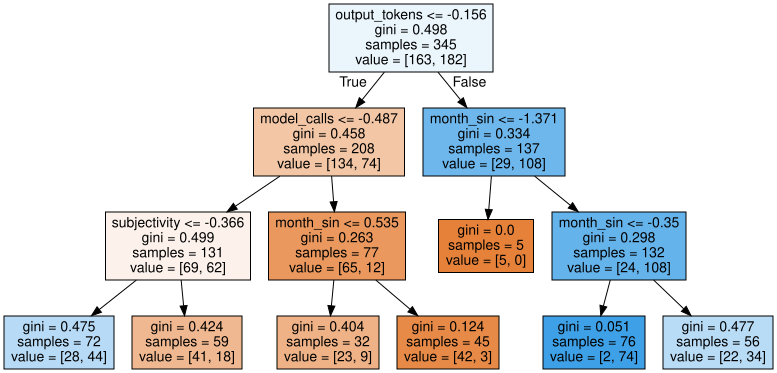

In [73]:
display(
  graphviz.Source(
    tree.export_graphviz(
      dt,
      feature_names = X.columns,
      filled = True,
    )))

<Axes: title={'center': 'Decision Tree Feature Importance'}>

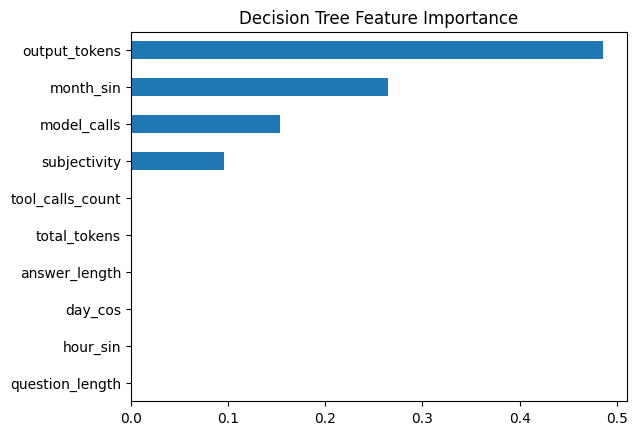

In [74]:
dt_importances.head(10).sort_values().plot(
  kind='barh',
  title='Decision Tree Feature Importance'
)

<Axes: title={'center': 'Random Forest Feature Importance'}>

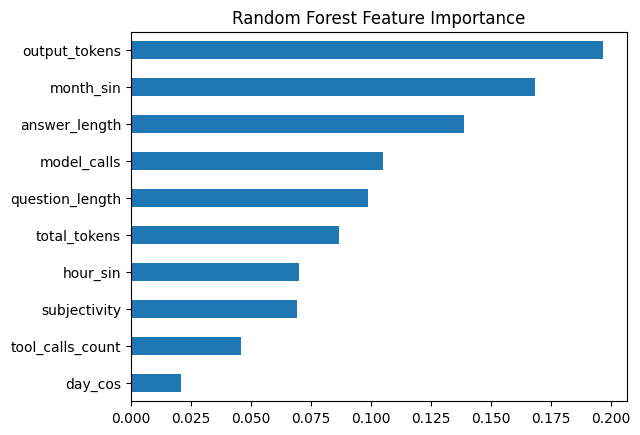

In [75]:
#Feature importance
forest_importances = pd.Series(
  rf.feature_importances_,
  index=features
).sort_values(ascending=False)

#Plot
forest_importances.head(10).sort_values().plot(
  kind='barh',
  title='Random Forest Feature Importance'
)

<Axes: title={'center': 'XGBoost Feature Importance'}>

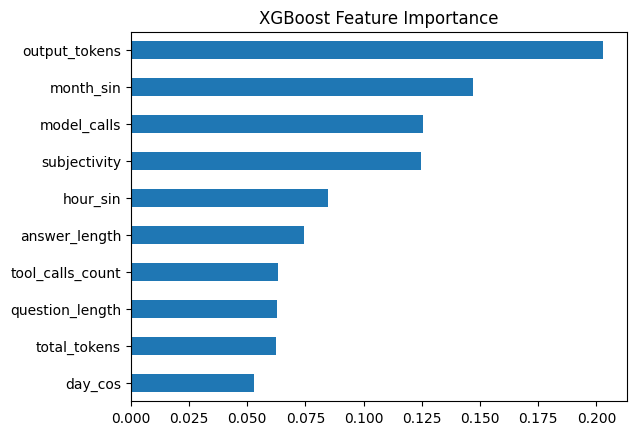

In [76]:
xgb_importances.head(10).sort_values().plot(
  kind='barh',
  title='XGBoost Feature Importance'
)

In [77]:
results = pd.DataFrame({
  'Model': ['Decision Tree', 'Random Forest', 'XGBoost'],

  'Accuracy': [
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_xgb)
  ],

  'F1': [
    f1_score(y_test, y_pred_dt),
    f1_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_xgb)
  ],

  'ROC-AUC': [
    roc_auc_score(y_test, y_prob_dt),
    roc_auc_score(y_test, y_prob_rf),
    roc_auc_score(y_test, y_prob_xgb)
  ]
})

results

,Model,Accuracy,F1,ROC-AUC
0,Decision Tree,0.712644,0.757282,0.796776
1,Random Forest,0.712644,0.725275,0.811839
2,XGBoost,0.678161,0.708333,0.800476


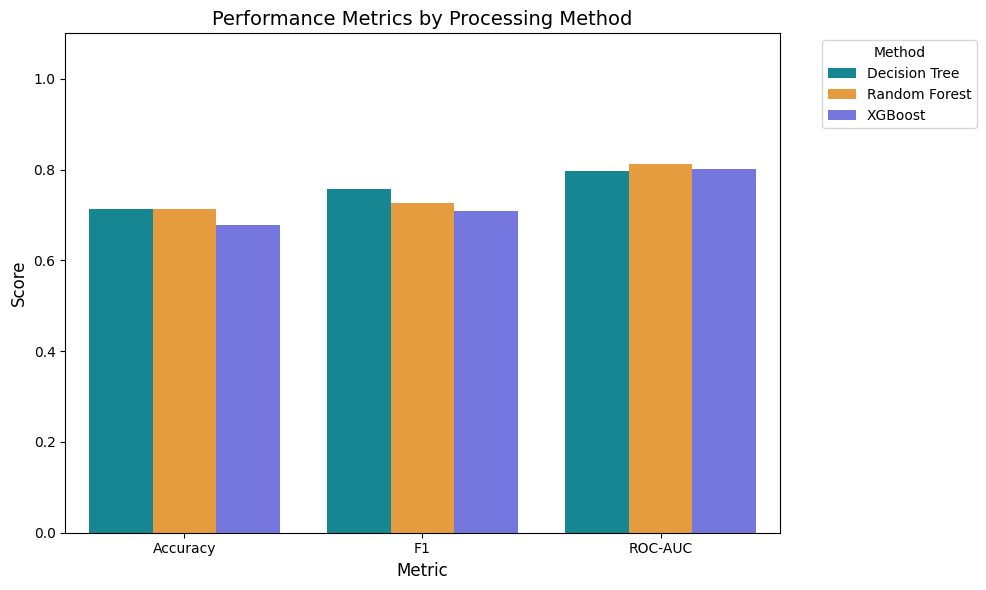

In [78]:
#Melt df to restructure for Seaborn
results_melted = results.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(
    data=results_melted,
    x='Metric',
    y='Score',
    hue='Model',
    palette=['#0097A7', '#FF9F24',  '#6366F1']
)

plt.title('Performance Metrics by Processing Method', fontsize=14)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Metric', fontsize=12)
plt.ylim(0, 1.1) #Headroom

#Move legend
plt.legend(title='Method', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig('evaluation.png', dpi=300, bbox_inches='tight')

plt.show()

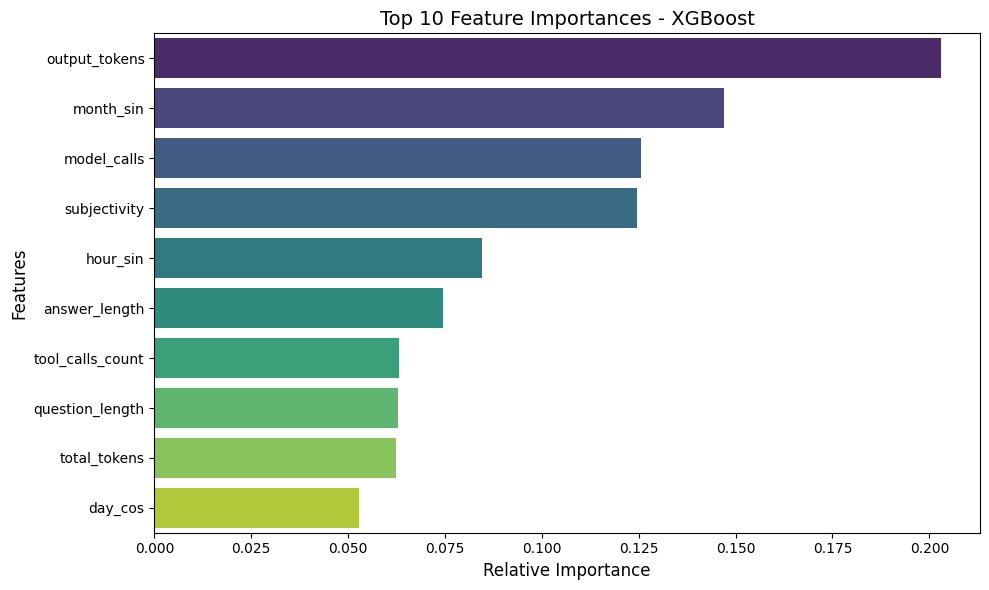

In [79]:
#Create df for XGBoost importance features
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': xgb.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))

#Create horizontal barplot
sns.barplot(
    data=feature_importance.head(10),
    x='importance',
    y='feature',
    hue='feature',
    palette='viridis',
    legend=False
)

plt.title('Top 10 Feature Importances - XGBoost', fontsize=14)
plt.xlabel('Relative Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)

plt.tight_layout()

plt.savefig('important_features.png', dpi=300, bbox_inches='tight')

plt.show()

##Communication of Results

In [80]:
importance_comparison = pd.DataFrame({
  'Decision Tree': dt_importances,
  'Random Forest': forest_importances,
  'XGBoost': xgb_importances
})

importance_comparison

,Decision Tree,Random Forest,XGBoost
answer_length,0.000000,0.138579,0.074410
day_cos,0.000000,0.020813,0.052763
hour_sin,0.000000,0.070050,0.084648
model_calls,0.153692,0.105112,0.125533
month_sin,0.264752,0.168438,0.146910
output_tokens,0.486043,0.196778,0.202920
question_length,0.000000,0.098596,0.062825
subjectivity,0.095513,0.069119,0.124487
tool_calls_count,0.000000,0.045720,0.063105
total_tokens,0.000000,0.086795,0.062398
